Este código deja el pipeline modulado (funciones reutilizables por año), centraliza el cálculo de outliers y la eliminación de variables correlacionadas, y define tres configuraciones: una optimizada de gradient Boosting, otra de Random Forest y dos de Redes Neuronales. Además, se ha incluido un bloque de RandomizedSearchCV que prueba decenas de combinaciones de forma sistemática. Se optimizan dichos modelos, entrenando con 2025 y evaluando con 2026. 
Se comprueba el drift de la inflacción del mercado de 2025 a 2026, verificando la naturaleza del "salto" de precio 2025->2026.

El esquema del trabajo que se plantea es:

1. Carga de datos: Leer los CSV de 2025 y 2026.
2. Ingeniería de variables: 

    a) Extracción de métricas de ocupación anuales del calendario, minería de texto sobre los títulos de los anuncios (detección de lujo, número de camas, vistas), extracción de amenities (equipamientos en los inmuebles) detalladas (desde archivos .gz tolerantes a fallos).
    
    b) Mapeo de variables, procedentes de Visión Artificial sobre imágenes generadas por IA, mediante ingeniería Geoespacial Avanzada (OSMnx):Conexión con OpenStreetMap, añadiendo nuevas columnas (ocio_500m, transporte_500m, distancia_ciutat_artes_m) a las tablas df_features_25 y df_features_26.

3. Ingesta y tratamiento de datos: Acotación del mercado objetivo eliminando valores atípicos (precios superiores a 800€/noche) para evitar que viviendas de hiper-lujo distorsionen el entrenamiento, y purga de variables prohibidas para evitar data leakage (fugas de información).
4. Análisis exploratorio de datos espaciales: de precios por barrio, de caída de precios por distancias, de precios con impacto de ocio y de calor de Presión Turística (KDE).
5. Preprocesado (ColumnTransformer): Escalado de variables numericas y transformación a ceros y unos de variables categóricas (como el tipo de habitación).
6. Estudios de modelos. Los algoritmos analizan el X_train (enriquecido con información de bares, metros y monumentos).
7. Entrenamiento con 2025 y evaluación en 2026.
7. Evaluación: Medición del RMSE y analisis de la importancia de variables.

**1. CARGA DE DATOS**

Este script está diseñado para detectar automáticamente si disponemos de los datos completos de Valencia para 2025 y 2026 (carpeta data/, cuyos archivos se pueden descargar de https://insideairbnb.com/es/get-the-data/) o si estamos ejecutando la versión de demostración de GitHub (carpeta data_sample/). Los datos se estructurarán en un diccionario llamado db, protegiendo la carga del .gz con avisos por si alguien los clona sin esos archivos pesados (calendar.csv.gz y listings.csv.gz).

In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import numpy as np

# 1. En Jupyter se usa Path.cwd() (Current Working Directory) en lugar de __file__
DIRECTORIO_ACTUAL = Path.cwd()

# Si se guarda el notebook dentro de la carpeta 'src/', se sube un nivel, si se guarda en la carpeta raíz, se mantiene.
if DIRECTORIO_ACTUAL.name == "src":
    DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
else:
    DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL

# 2. Detección de los datos reales o se usan la muestra de GitHub
if (DIRECTORIO_RAIZ / "data").exists():
    DIRECTORIO_DATOS = DIRECTORIO_RAIZ / "data"
    print("Usando carpeta de datos REALES (data/)")
else:
    DIRECTORIO_DATOS = DIRECTORIO_RAIZ / "data_sample"
    print("Usando carpeta de datos de MUESTRA descargada de GitHub (data_sample/)")

def cargar_listings_detallado(ruta_gz):
    """Extrae características avanzadas desde listings.csv.gz (Tolerante a fallos para GitHub)"""
    if not ruta_gz.exists():
        print(f"Aviso GitHub: No se encontró {ruta_gz.name}. Se omitirán las variables detalladas.")
        return None
        
    cols = ["id", "accommodates", "bedrooms", "beds", "bathrooms_text",
            "amenities", "property_type", "review_scores_rating",
            "review_scores_location", "review_scores_cleanliness",
            "host_is_superhost", "instant_bookable"]
    
    df = pd.read_csv(ruta_gz, compression="gzip", low_memory=False)
    df = df[[c for c in cols if c in df.columns]].copy()
    
    if "bathrooms_text" in df.columns:
        num = df["bathrooms_text"].astype(str).str.extract(r"([\d\.]+)")[0].astype(float)
        compartido = df["bathrooms_text"].astype(str).str.contains("shared", case=False, na=False)
        df["bathrooms_num"] = np.where(compartido, num / 2, num)
        df = df.drop(columns=["bathrooms_text"])
    
    if "amenities" in df.columns:
        df["n_amenities"] = df["amenities"].astype(str).str.count(",") + 1
        for clave, etiqueta in [("Pool", "am_piscina"), ("Air conditioning", "am_aire"),
                                ("Elevator", "am_ascensor"), ("Free parking", "am_parking"),
                                ("Balcony", "am_balcon"), ("Sea view", "am_vistas_mar")]:
            df[etiqueta] = df["amenities"].astype(str).str.contains(clave, case=False).astype(int)
        df = df.drop(columns=["amenities"])
        
    if "accommodates" in df.columns and "bedrooms" in df.columns:
        df["personas_por_dormitorio"] = df["accommodates"] / df["bedrooms"].replace(0, np.nan)
        
    return df.rename(columns={"id": "listing_id"})

def cargar_datos_año(año):
    """Carga los archivos de un año específico."""
    ruta_año = DIRECTORIO_DATOS / str(año)
    print(f"Cargando datos del año {año}...")
    
    datos = {
        "listings": pd.read_csv(ruta_año / "listings.csv", low_memory=False),
        "reviews": pd.read_csv(ruta_año / "reviews.csv", low_memory=False),
        "calendar": pd.read_csv(ruta_año / "calendar.csv.gz", compression='gzip', low_memory=False),
        "neigh": pd.read_csv(ruta_año / "neighbourhoods.csv"),
        "mapa_barrios": gpd.read_file(ruta_año / "neighbourhoods.geojson")
    }
    datos["listings_detallado"] = cargar_listings_detallado(ruta_año / "listings.csv.gz")
    return datos

# 3. Cargar los datos
db = {}
for año in [2025, 2026]:
    if (DIRECTORIO_DATOS / str(año)).exists():
        db[str(año)] = cargar_datos_año(año)

df_listings = db["2025"]["listings"]
df_listings.head()

Usando carpeta de datos REALES (data/)
Cargando datos del año 2025...
Cargando datos del año 2026...


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,48154,Precioso apartamento con wifi,219476,Antonio,LA SAIDIA,MORVEDRE,39.48375,-0.37502,Entire home/apt,83.0,3,197,2025-09-15,1.08,4,150,26,VT-41540-V
1,137143,PENTHOUSE ON FRONT LINE BEACH,670775,Maria De La Piedad,POBLATS DEL SUD,EL SALER,39.36335,-0.31932,Entire home/apt,390.0,10,1,2013-07-02,0.01,5,20,0,VT32745V
2,149715,1900 Style Valencian Beach Home for 10px,5947,Susana Barbara,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.46746,-0.32813,Entire home/apt,245.0,2,313,2025-09-15,1.81,1,287,41,ESFCTU000046025000580569000000000000000000VT-3...
3,165971,★ Architectural touch! ★,791187,Inés,EXTRAMURS,LA ROQUETA,39.46790,-0.38206,Entire home/apt,124.0,5,576,2025-09-03,3.34,8,106,46,VT-32757-V
4,182221,Apartments Calatrava City Valencia,1315567,Chiara,CAMINS AL GRAU,AIORA,39.46343,-0.34325,Entire home/apt,137.0,3,9,2025-03-17,0.07,1,176,1,VT-38755-V


**1.a Extracción de variables para el EDA de 2025**

    DataFrames del diccionario para trabajar de forma más cómoda con las tablas del año 2025.

In [2]:
df_listings_25 = db["2025"]["listings"]
df_reviews_25  = db["2025"]["reviews"]
df_calendar_25 = db["2025"]["calendar"]
df_neigh_25    = db["2025"]["neigh"]
mapa_25        = db["2025"]["mapa_barrios"]
df_detallado_25 = db["2025"].get("listings_detallado")

print("Tablas listas para el análisis.")

Tablas listas para el análisis.


**1.b Extracción de variables para el EDA de 2026**

    DataFrames del diccionario para trabajar de forma más cómoda con las tablas del año 2026.

In [3]:
df_listings_26 = db["2026"]["listings"]
df_reviews_26  = db["2026"]["reviews"]
df_calendar_26 = db["2026"]["calendar"]
df_neigh_26    = db["2026"]["neigh"]
mapa_26        = db["2026"]["mapa_barrios"]
df_detallado_26 = db["2026"].get("listings_detallado")

print("Tablas listas para el análisis.")

Tablas listas para el análisis.


**1.c. Ver información básica**

In [4]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,48154,Precioso apartamento con wifi,219476,Antonio,LA SAIDIA,MORVEDRE,39.48375,-0.37502,Entire home/apt,83.0,3,197,2025-09-15,1.08,4,150,26,VT-41540-V
1,137143,PENTHOUSE ON FRONT LINE BEACH,670775,Maria De La Piedad,POBLATS DEL SUD,EL SALER,39.36335,-0.31932,Entire home/apt,390.0,10,1,2013-07-02,0.01,5,20,0,VT32745V
2,149715,1900 Style Valencian Beach Home for 10px,5947,Susana Barbara,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.46746,-0.32813,Entire home/apt,245.0,2,313,2025-09-15,1.81,1,287,41,ESFCTU000046025000580569000000000000000000VT-3...
3,165971,★ Architectural touch! ★,791187,Inés,EXTRAMURS,LA ROQUETA,39.46790,-0.38206,Entire home/apt,124.0,5,576,2025-09-03,3.34,8,106,46,VT-32757-V
4,182221,Apartments Calatrava City Valencia,1315567,Chiara,CAMINS AL GRAU,AIORA,39.46343,-0.34325,Entire home/apt,137.0,3,9,2025-03-17,0.07,1,176,1,VT-38755-V


,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,48154,Precioso apartamento con wifi,219476.0,1.462513e+18,Antonio,LA SAIDIA,MORVEDRE,39.483750,-0.375020,Entire home/apt,146.0,2.0,223,2026-06-14,1.17,4.0,98,35,Valencia - Regional registration number<br />V...
1,137143,PENTHOUSE ON FRONT LINE BEACH,670775.0,1.462526e+18,Attico Valencia,POBLATS DEL SUD,EL SALER,39.363350,-0.319320,Entire home/apt,NaN,10.0,1,2013-07-02,0.01,5.0,0,0,Valencia - Regional registration number<br />V...
2,149715,1900 Style Valencian Beach Home for 10px,5947.0,1.462507e+18,Susana Barbara,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.467460,-0.328130,Entire home/apt,485.0,1.0,344,2026-06-21,1.89,1.0,258,43,Spain - National registration number<br />ESFC...
3,165971,★ Architectural touch! ★,791187.0,1.462530e+18,Inés,EXTRAMURS,LA ROQUETA,39.467900,-0.382060,Entire home/apt,211.0,1.0,612,2026-05-28,3.37,12.0,97,47,Valencia - Regional registration number<br />V...
4,182221,Apartments Calatrava City Valencia,1315567.0,1.462517e+18,Patente Lino,CAMINS AL GRAU,AIORA,39.463212,-0.343279,Entire home/apt,352.0,3.0,10,2026-01-04,0.08,2.0,149,1,Valencia - Regional registration number<br />V...


,listing_id,date
0,48154,2010-10-12
1,48154,2010-11-28
2,48154,2011-03-01
3,48154,2011-03-08
4,48154,2011-04-05


,listing_id,date
0,39840290,2019-11-12
1,39840290,2019-11-20
2,39840290,2019-12-03
3,39840290,2019-12-08
4,39840290,2020-01-11


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,2053439,2025-09-24,f,NaN,NaN,3,30
1,2053439,2025-09-25,f,NaN,NaN,3,30
2,2053439,2025-09-26,t,NaN,NaN,3,30
3,2053439,2025-09-27,f,NaN,NaN,3,30
4,2053439,2025-09-28,f,NaN,NaN,3,30


,listing_id,date,available,minimum_nights,maximum_nights
0,48154,2026-06-27,f,3,25
1,48154,2026-06-28,f,3,25
2,48154,2026-06-29,f,3,25
3,48154,2026-06-30,f,3,25
4,48154,2026-07-01,f,3,25


,neighbourhood_group,neighbourhood
0,ALGIROS,CIUTAT JARDI
1,ALGIROS,LA CARRASCA
2,ALGIROS,L'AMISTAT
3,ALGIROS,LA VEGA BAIXA
4,ALGIROS,L'ILLA PERDUDA


,neighbourhood_group,neighbourhood
0,ALGIROS,CIUTAT JARDI
1,ALGIROS,LA CARRASCA
2,ALGIROS,L'AMISTAT
3,ALGIROS,LA VEGA BAIXA
4,ALGIROS,L'ILLA PERDUDA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7844 entries, 0 to 7843
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   listing_id                 7844 non-null   int64  
 1   accommodates               7844 non-null   int64  
 2   bedrooms                   7532 non-null   float64
 3   beds                       6976 non-null   float64
 4   property_type              7844 non-null   object 
 5   review_scores_rating       6867 non-null   float64
 6   review_scores_location     6866 non-null   float64
 7   review_scores_cleanliness  6867 non-null   float64
 8   host_is_superhost          7454 non-null   object 
 9   instant_bookable           7844 non-null   object 
 10  bathrooms_num              7733 non-null   float64
 11  n_amenities                7844 non-null   int64  
 12  am_piscina                 7844 non-null   int64  
 13  am_aire                    7844 non-null   int64

,listing_id,accommodates,bedrooms,beds,review_scores_rating,review_scores_location,review_scores_cleanliness,bathrooms_num,n_amenities,am_piscina,am_aire,am_ascensor,am_parking,am_balcon,am_vistas_mar,personas_por_dormitorio
count,7.844000e+03,7844.000000,7532.000000,6976.000000,6867.000000,6866.000000,6867.000000,7733.000000,7844.000000,7844.000000,7844.000000,7844.000000,7844.000000,7844.000000,7844.000000,7090.000000
mean,8.243448e+17,3.505609,1.537440,2.156823,4.658922,4.674837,4.668585,1.170471,30.617160,0.033146,0.685237,0.338348,0.094977,0.337455,0.003187,2.379873
std,5.535320e+17,1.880761,0.988074,1.521103,0.451586,0.391328,0.446722,0.566482,15.009153,0.179030,0.464451,0.473178,0.293202,0.472872,0.056368,1.078646
min,4.815400e+04,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.117647
25%,5.086848e+07,2.000000,1.000000,1.000000,4.560000,4.560000,4.560000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,1.020877e+18,4.000000,1.000000,2.000000,4.770000,4.760000,4.790000,1.000000,31.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,1.295046e+18,4.000000,2.000000,3.000000,4.910000,4.920000,4.930000,1.000000,41.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000
max,1.514336e+18,16.000000,17.000000,23.000000,5.000000,5.000000,5.000000,11.500000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16.000000


<Axes: >

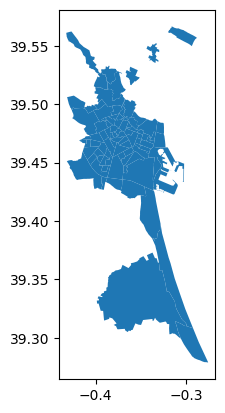

In [5]:
df_listings_25.head()
df_listings_26.head()
df_reviews_25.head()
df_reviews_26.head()
df_calendar_25.head()
df_calendar_26.head()
df_neigh_25.head()
df_neigh_26.head()


# Ver la información básica y valores nulos
df_detallado_25.info()

# Ver estadísticas descriptivas básicas de listings_detallado_25 (si existe en entorno local (carpeta data/))
display(df_detallado_25.describe())

# Pintar el mapa de barrios rápidamente
mapa_25.plot()

In [6]:
# ============================================
#  Importación de librerías adicionales
# ============================================

from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

**2. INGENIERÍA DE VARIABLES**

**2.a. Mapeo de variables: Ingeniería de Variables Geoespaciales**

In [7]:
import osmnx as ox
from shapely.geometry import Point

# Configurar OSMnx para usar caché y no saturar el servidor si se ejecutas varias veces
ox.settings.use_cache = True
ox.settings.log_console = True

def enriquecer_entorno_osmnx(df_features, ciudad="Valencia, Spain"):
    """
    Enriquece un dataframe de Airbnbs con datos de puntos de interés (POIs) de OpenStreetMap.
    """
    print(f"Iniciando enriquecimiento geoespacial para {len(df_features)} alojamientos...")
    df = df_features.copy()
    
    # 1. Convertir el DataFrame de Pandas a un GeoDataFrame (Mapa de puntos)
    geometria = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
    gdf_airbnb = gpd.GeoDataFrame(df, geometry=geometria, crs="EPSG:4326") # EPSG:4326 = Coordenadas GPS normales
    
    #=========================================================
    # PROYECCIÓN UTM (para calcular distancias en metros reales)
    #=======================================================================
    
    # Se proyecta Valencia al sistema UTM Zona 30N (EPSG:25830)
    gdf_airbnb = gdf_airbnb.to_crs(epsg=25830)
    
    # 2. Descargar restaurantes, bares y cafeterías de OpenStreetMap
    print("   -> Descargando datos de Ocio de OSM (Puede tardar un par de minutos la primera vez)...")
    tags_ocio = {"amenity": ["restaurant", "cafe", "bar", "pub"]}
    gdf_ocio = ox.features_from_place(ciudad, tags_ocio)
    
    # Considerar solo con centroides (por si OSM devuelve el plano de un edificio) y proyectar a metros
    gdf_ocio['geometry'] = gdf_ocio.geometry.centroid
    gdf_ocio = gdf_ocio.to_crs(epsg=25830)
    
    # 3. Descargar estaciones de metro/transporte
    print("   -> Descargando datos de Transporte de OSM...")
    tags_transporte = {"railway": ["station", "subway_entrance"]}
    gdf_transporte = ox.features_from_place(ciudad, tags_transporte)
    gdf_transporte['geometry'] = gdf_transporte.geometry.centroid
    gdf_transporte = gdf_transporte.to_crs(epsg=25830)

    # ====================================================================
    # CÁLCULO DE DENSIDAD (¿Cuántos locales hay a 500m a la redonda?)
    #====================================================================
    
    print("   -> Calculando densidad de servicios en un radio de 500m...")
    # Creamos un círculo de 500 metros exactos alrededor de cada Airbnb
    gdf_airbnb_buffer = gdf_airbnb.copy()
    gdf_airbnb_buffer.geometry = gdf_airbnb_buffer.geometry.buffer(500)
    
    # Cruce espacial: ¿Qué locales caen dentro de cada círculo?
    cruce_ocio = gpd.sjoin(gdf_ocio, gdf_airbnb_buffer, how="inner", predicate="within")
    cruce_transporte = gpd.sjoin(gdf_transporte, gdf_airbnb_buffer, how="inner", predicate="within")
    
    # Contar cuántos locales hay por cada índice de alojamiento
    conteos_ocio = cruce_ocio.groupby('index_right').size()
    conteos_transporte = cruce_transporte.groupby('index_right').size()
    
    # Mapear los resultados a nuestro dataframe original (Rellenando con 0 si no hay nada cerca)
    df['ocio_500m'] = df.index.map(conteos_ocio).fillna(0)
    df['transporte_500m'] = df.index.map(conteos_transporte).fillna(0)

    # ========================================================================================
    # DISTANCIA EXACTA A UN PUNTO DE INTERÉS CLAVE (Ej: Ciudad de las Artes y las Ciencias)
    #=======================================================================================
    
    print("   -> Calculando distancias a la Ciudad de las Artes...")
    # Coordenadas GPS de la Ciutat de les Arts: Latitud 39.4542, Longitud -0.3503
    punto_ciutat = gpd.GeoSeries([Point(-0.3503, 39.4542)], crs="EPSG:4326").to_crs(epsg=25830)
    
    # Distancia en línea recta desde cada piso al monumento (en metros)
    df['distancia_ciutat_artes_m'] = gdf_airbnb.geometry.distance(punto_ciutat.iloc[0])

    print("¡Enriquecimiento geoespacial completado!")
    return df


**2.b. Funciones de feature engineering para un año (pipeline reutilizable unificado)**

In [8]:
# Configurar OSMnx para usar caché y evitar descargas repetidas
ox.settings.use_cache = True
ox.settings.log_console = True

# Coordenadas de referencia (Latitud, Longitud)

VALENCIA_CENTER = (39.4702, -0.3768)  
VALENCIA_BEACH = (39.4680, -0.3200)   
CIUTAT_ARTES = (39.4542, -0.3503)

def preparar_listings(df_listings, df_neigh):
    """Limpia y enriquece la tabla de anuncios con el CSV de barrios."""
    df = df_listings.copy()
    if "neighbourhood_group" not in df.columns and "neighbourhood_group" in df_neigh.columns:
        df = df.merge(
            df_neigh[["neighbourhood", "neighbourhood_group"]],
            on="neighbourhood",
            how="left",
            suffixes=("", "_neigh")
        )
    return df

def agregar_calendar_por_listing(df_calendar):
    """Agrega la tabla de calendar por listing_id para obtener métricas anuales."""
    df = df_calendar.copy()
    if not np.issubdtype(df["date"].dtype, np.datetime64):
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    
    df["year"] = df["date"].dt.year
    if "listing_id" not in df.columns and "id" in df.columns:
        df = df.rename(columns={"id": "listing_id"})

    df["available_flag"] = df["available"].map({"t": 1, "f": 0})
    df["booked_flag"] = 1 - df["available_flag"]

    if "price" in df.columns:
        if df["price"].dtype == object:
            df["price"] = df["price"].astype(str).str.replace(r"[^0-9\.\-]", "", regex=True).replace("", np.nan).astype(float)
        df["revenue_day"] = df["price"] * df["booked_flag"]
        agregaciones = df.groupby(["listing_id", "year"]).agg(
            availability_365=("available_flag", "sum"),
            total_booked_days=("booked_flag", "sum"),
            avg_daily_price_year=("price", "mean"),
            total_revenue_year=("revenue_day", "sum"),
        ).reset_index()
    else:
        print("Aviso: No se encontró 'price' en el calendar. Omitiendo cálculo de ingresos.")
        agregaciones = df.groupby(["listing_id", "year"]).agg(
            availability_365=("available_flag", "sum"),
            total_booked_days=("booked_flag", "sum")
        ).reset_index()
        agregaciones["avg_daily_price_year"] = np.nan
        agregaciones["total_revenue_year"] = np.nan

    total_dias = agregaciones["availability_365"] + agregaciones["total_booked_days"]
    agregaciones["occupancy_rate_year"] = np.where(total_dias > 0, agregaciones["total_booked_days"] / total_dias, 0)
    return agregaciones


def enriquecimiento_geoespacial_total(df, ciudad="Valencia, Spain"):
    """
    Sustituye a la antigua función Haversine.
    Usa GeoPandas y proyecciones UTM para distancias exactas y extrae POIs de OSM.
    """
    print(f"Iniciando enriquecimiento geoespacial para {len(df)} alojamientos...")
    df_geo = df.copy()
    
    # 1. Convertir a GeoDataFrame y proyectar a UTM Zona 30N (EPSG:25830)

    geometria = [Point(xy) for xy in zip(df_geo['longitude'], df_geo['latitude'])]
    gdf_airbnb = gpd.GeoDataFrame(df_geo, geometry=geometria, crs="EPSG:4326")
    gdf_airbnb = gdf_airbnb.to_crs(epsg=25830)
    
    # 2. Convertir puntos de referencia a UTM (Nota: Point recibe Longitud, Latitud)

    puntos_referencia = gpd.GeoSeries([
        Point(VALENCIA_CENTER[1], VALENCIA_CENTER[0]),
        Point(VALENCIA_BEACH[1], VALENCIA_BEACH[0]),
        Point(CIUTAT_ARTES[1], CIUTAT_ARTES[0])
    ], crs="EPSG:4326").to_crs(epsg=25830)
    
    # 3. Distancias exactas (en metros) de forma vectorizada

    print("-> Calculando distancias al Centro, Playa y Ciudad de las Artes...")
    df_geo["dist_to_center_m"] = gdf_airbnb.geometry.distance(puntos_referencia.iloc[0])
    df_geo["dist_to_beach_m"] = gdf_airbnb.geometry.distance(puntos_referencia.iloc[1])
    df_geo["dist_to_arts_m"] = gdf_airbnb.geometry.distance(puntos_referencia.iloc[2])
    
    # 4. OSMnx: Descargar Ocio y Transporte

    print("-> Descargando datos de Ocio y Transporte de OpenStreetMap...")
    gdf_ocio = ox.features_from_place(ciudad, {"amenity": ["restaurant", "cafe", "bar", "pub"]})
    gdf_ocio['geometry'] = gdf_ocio.geometry.centroid
    gdf_ocio = gdf_ocio.to_crs(epsg=25830)
    
    gdf_transporte = ox.features_from_place(ciudad, {"railway": ["station", "subway_entrance"]})
    gdf_transporte['geometry'] = gdf_transporte.geometry.centroid
    gdf_transporte = gdf_transporte.to_crs(epsg=25830)

    # 5. Cruce espacial (buffer 500m)

    print("-> Calculando densidad de servicios (radio 500m)...")
    gdf_airbnb_buffer = gdf_airbnb.copy()
    gdf_airbnb_buffer.geometry = gdf_airbnb_buffer.geometry.buffer(500)
    
    cruce_ocio = gpd.sjoin(gdf_ocio, gdf_airbnb_buffer, how="inner", predicate="within")
    cruce_transporte = gpd.sjoin(gdf_transporte, gdf_airbnb_buffer, how="inner", predicate="within")
    
    df_geo['ocio_500m'] = df_geo.index.map(cruce_ocio.groupby('index_right').size()).fillna(0)
    df_geo['transporte_500m'] = df_geo.index.map(cruce_transporte.groupby('index_right').size()).fillna(0)

    print("¡Enriquecimiento geoespacial completado!")
    return df_geo


def features_desde_titulo(df):
    """Extrae información clave de los títulos de los anuncios."""
    if "name" not in df.columns:
        return df
    t = df["name"].fillna("").str.lower()
    df["tit_n_dorm"] = t.str.extract(r"(\d+)\s*(?:bed|bd|dorm|hab)")[0].astype(float)
    df["tit_n_huesp"] = t.str.extract(r"(?:for|para|sleeps)\s*(\d+)")[0].astype(float)
    df["tit_rating"] = t.str.extract(r"★([\d\.]+)")[0].astype(float)
    df["tit_es_lujo"] = t.str.contains("luxur|lujo|penthouse|ático|premium|design").astype(int)
    df["tit_vistas"] = t.str.contains("sea view|beach|playa|vistas|mar").astype(int)
    df["tit_centro"] = t.str.contains("centro|center|old town|ciutat vella").astype(int)
    df["tit_longitud"] = t.str.len()
    return df

def construir_dataset_anual(df_listings, df_calendar, df_neigh, mapa_barrios, year_label, df_imagenes=None, df_listings_detallado=None):
    """Construye el dataset de features a nivel de anuncio integrando todo."""

    # 1. Preparar listings y calendar base
    df_limpio = preparar_listings(df_listings, df_neigh)
    df_cal_agregado = agregar_calendar_por_listing(df_calendar)
    
    df_cal_year = df_cal_agregado[df_cal_agregado["year"] == year_label].copy()
    
    if "id" in df_limpio.columns and "listing_id" not in df_limpio.columns:
        df_limpio = df_limpio.rename(columns={"id": "listing_id"})

    # 2. Unir listings con métricas de calendar
    df_features = df_limpio.merge(
        df_cal_year.drop(columns=["year"]),
        on="listing_id",
        how="left"
    )

    # 3. Merge con variables extendidas de listings.csv.gz (si existen)
    if df_listings_detallado is not None:
        df_features = df_features.merge(
            df_listings_detallado,
            on="listing_id",
            how="left"
        )

    # 4. Enriquecimiento geoespacial (Centro, Playa, OSMnx)
    df_features = enriquecimiento_geoespacial_total(df_features)
    
    # 5. Integración de variables de Visión Artificial (Imágenes)
    if df_imagenes is not None:
        print("-> Integrando características de Visión Artificial (Imágenes)...")
        df_features = df_features.merge(df_imagenes, on="listing_id", how="left")
        cols_img = [col for col in df_imagenes.columns if col.startswith("img_has_")]
        df_features[cols_img] = df_features[cols_img].fillna(0)
        
    print(f"Dataset de {year_label} construido con {df_features.shape[1]} variables.")
    return df_features

**3. INGESTA Y TRATAMIENTO DE DATOS**

**3.a. Construcción de datasets 2025 (train) y 2026 (test)**

In [9]:
import os

# Se intenta cargar los CSVs de imágenes (Visión Artificial) si existen
ruta_img_25 = DIRECTORIO_RAIZ / "data" / "features_imagenes_2025.csv"
ruta_img_26 = DIRECTORIO_RAIZ / "data" / "features_imagenes_2026.csv"

# Se leen los datos offline (si no existen, será None y la función lo ignorará sin dar error)
df_img_25 = pd.read_csv(ruta_img_25) if ruta_img_25.exists() else None
df_img_26 = pd.read_csv(ruta_img_26) if ruta_img_26.exists() else None

if df_img_25 is not None:
    print("Archivo de Visión Artificial de 2025 detectado.")

# Se construyen los datasets finales pasando el parámetro extra de detallado
df_features_25 = construir_dataset_anual(
    df_listings=df_listings_25,
    df_calendar=df_calendar_25,
    df_neigh=df_neigh_25,
    mapa_barrios=mapa_25,
    year_label=2025,
    df_imagenes=df_img_25,
    df_listings_detallado=df_detallado_25 # <-- Se pasa la tabla avanzada
)

df_features_26 = construir_dataset_anual(
    df_listings=df_listings_26,
    df_calendar=df_calendar_26,
    df_neigh=df_neigh_26,
    mapa_barrios=mapa_26,
    year_label=2026,
    df_imagenes=df_img_26,
    df_listings_detallado=df_detallado_26 # <-- Se pasa la tabla avanzada
)

# Se aplican las features de texto del título a los datasets ya fusionados
df_features_25 = features_desde_titulo(df_features_25)
df_features_26 = features_desde_titulo(df_features_26)

print("Datasets de features construidos para 2025 y 2026.")

Archivo de Visión Artificial de 2025 detectado.
Iniciando enriquecimiento geoespacial para 7844 alojamientos...
-> Calculando distancias al Centro, Playa y Ciudad de las Artes...
-> Descargando datos de Ocio y Transporte de OpenStreetMap...


C:\Users\Marilo-TURBO\AppData\Local\Temp\ipykernel_30696\1404108196.py:93: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ocio['geometry'] = gdf_ocio.geometry.centroid
C:\Users\Marilo-TURBO\AppData\Local\Temp\ipykernel_30696\1404108196.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_transporte['geometry'] = gdf_transporte.geometry.centroid


-> Calculando densidad de servicios (radio 500m)...
¡Enriquecimiento geoespacial completado!
-> Integrando características de Visión Artificial (Imágenes)...
Dataset de 2025 construido con 50 variables.
Aviso: No se encontró 'price' en el calendar. Omitiendo cálculo de ingresos.
Iniciando enriquecimiento geoespacial para 7865 alojamientos...
-> Calculando distancias al Centro, Playa y Ciudad de las Artes...
-> Descargando datos de Ocio y Transporte de OpenStreetMap...


C:\Users\Marilo-TURBO\AppData\Local\Temp\ipykernel_30696\1404108196.py:93: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ocio['geometry'] = gdf_ocio.geometry.centroid
C:\Users\Marilo-TURBO\AppData\Local\Temp\ipykernel_30696\1404108196.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_transporte['geometry'] = gdf_transporte.geometry.centroid


-> Calculando densidad de servicios (radio 500m)...
¡Enriquecimiento geoespacial completado!
-> Integrando características de Visión Artificial (Imágenes)...
Dataset de 2026 construido con 51 variables.
Datasets de features construidos para 2025 y 2026.


**3.b. Definición de funciones auxiliares para análisis de outliers y selección de variables**

In [10]:
def resumen_outliers_iqr(df, columnas_numericas, nombre_df="df"):
    """
    Calcula el resumen de outliers por IQR para un conjunto de columnas numéricas.
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame sobre el que se calculan los outliers.
    columnas_numericas : list of str
        Nombres de las columnas numéricas a analizar.
    nombre_df : str
        Nombre lógico del dataframe (para identificar en prints/logs).
    
    Returns
    -------
    pd.DataFrame
        Tabla con Q1, Q3, IQR, límites inferior/superior y número/porcentaje de outliers.
    """
    resultados = []

    for col in columnas_numericas:
        serie = df[col].dropna()
        if serie.empty:
            continue

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
        n_outliers = len(outliers)
        pct_outliers = n_outliers / len(serie) * 100

        resultados.append({
            "dataframe": nombre_df,
            "columna": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "n_outliers": n_outliers,
            "pct_outliers": pct_outliers
        })

    return pd.DataFrame(resultados)


def eliminar_variables_correlacionadas(df, columnas_numericas, umbral=0.9, mostrar_grafico=False):
    """
    Identifica y elimina variables numéricas altamente correlacionadas.
    
    Estrategia:
    - Se calcula la matriz de correlaciones absolutas.
    - Para cada par con correlación > umbral, se elimina una de las dos columnas.
      Aquí se mantiene la primera columna y se elimina la siguiente.
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada (no se modifica in-place).
    columnas_numericas : list of str
        Lista de columnas numéricas a considerar.
    umbral : float
        Umbral de correlación absoluta por encima del cual se elimina una variable.
        
    Returns
    -------
    df_filtrado : pd.DataFrame
        Copia del dataframe sin las columnas altamente correlacionadas.
    columnas_eliminadas : list of str
        Lista de nombres de columnas que se han eliminado.
    """
    df_num = df[columnas_numericas].copy()
    corr_matrix = df_num.corr().abs()

    if mostrar_grafico:
        plt.figure(figsize=(12, 10))
        # Pintamos el heatmap. annot=False para que no se sature de números
        sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
        plt.title(f"Matriz de Correlación Absoluta (Umbral de corte: {umbral})", fontsize=15)
        plt.tight_layout()
        plt.show()

    # Triángulo superior de la matriz de correlación
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    columnas_eliminar = [
        column for column in upper.columns 
        if any(upper[column] > umbral)
    ]

    df_filtrado = df.drop(columns=columnas_eliminar, errors="ignore")

    return df_filtrado, columnas_eliminar

**3.c. Análisis de outliers (resumen, no transformación automática)**

In [11]:
columnas_numericas_base = [
    col for col in df_features_25.select_dtypes(include=[np.number]).columns
    if col not in ["listing_id", "host_id", "host_profile_id"]
]

resumen_outliers_25 = resumen_outliers_iqr(
    df_features_25,
    columnas_numericas_base,
    nombre_df="features_2025"
)

resumen_outliers_26 = resumen_outliers_iqr(
    df_features_26,
    columnas_numericas_base,
    nombre_df="features_2026"
)

display(resumen_outliers_25.head())
display(resumen_outliers_26.head())

,dataframe,columna,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
0,features_2025,latitude,39.461480,39.474893,0.013413,39.441361,39.495011,315,4.015808
1,features_2025,longitude,-0.379972,-0.344124,0.035849,-0.433746,-0.290350,17,0.216726
2,features_2025,price,71.000000,140.000000,69.000000,-32.500000,243.500000,419,6.003725
3,features_2025,minimum_nights,1.000000,5.000000,4.000000,-5.000000,11.000000,810,10.326364
4,features_2025,number_of_reviews,3.000000,58.250000,55.250000,-79.875000,141.125000,863,11.002040


,dataframe,columna,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
0,features_2026,latitude,39.461967,39.475130,0.013163,39.442222,39.494875,364,4.628099
1,features_2026,longitude,-0.379957,-0.344071,0.035886,-0.433786,-0.290243,23,0.292435
2,features_2026,price,104.000000,201.000000,97.000000,-41.500000,346.500000,383,5.260266
3,features_2026,minimum_nights,1.000000,10.000000,9.000000,-12.500000,23.500000,415,5.278555
4,features_2026,number_of_reviews,3.000000,69.000000,66.000000,-96.000000,168.000000,771,9.802924


**3.d. Preparación de variables para modelización**

Se aplica transformación logarítmica porque:

Se transforma el target porque el precio de un alojamiento no se forma sumando euros, sino multiplicando porcentajes: un ático con vistas no vale "+120 € que un estudio", vale "un 80% más". Al aplicar np.log1p(price), convierto esa estructura multiplicativa en aditiva, que es precisamente la que los modelos de regresión saben aprender.

Además, del describe de outliers de 2025 y 2026 se puede concluir que: 

1. La diferencia entre cuartiles cambia un +41% de un año a otro, pero el ratio Q3/Q1 se mantiene prácticamente idéntico (1,97 vs 1,93). Es la demostración empírica de que la dispersión de precios es constante en términos relativos, no absolutos. En escala logarítmica log(𝑄3)−log(𝑄1) es una cantidad estable; en euros, no lo es. Trabajar en logaritmos es, por tanto, trabajar en la escala donde los datos son homogéneos.

2.  El precio tiene un suelo en 0 y no tiene techo, así que su distribución está inevitablemente sesgada a la derecha. El análisis IQR lo confirma: 419 outliers en price (6,0% de los casos) y un límite inferior teórico de −32,50 €, un valor imposible. Cuando el límite inferior de un IQR es negativo, es la señal clásica de que la variable no es simétrica y no debería modelarse en su escala original.

In [12]:
# Variable objetivo: precio de anuncio (LOG)
TARGET_COL = "price"

# Se filtran filas con precio no disponible
df_train = df_features_25.dropna(subset=[TARGET_COL]).copy()
df_test = df_features_26.dropna(subset=[TARGET_COL]).copy()

# (El enriquecimiento geoespacial ya se hizo automáticamente 
# en el paso 3.a al usar la función "construir_dataset_anual", no hace falta repetirlo aquí)

# =================================================================================
# DEFINICIÓN DEL MERCADO OBJETIVO (BUSINESS SCOPE) - TRATAMIENTO DE OUTLIERS
# =================================================================================
# Se limita el análisis al mercado estándar y premium razonable (hasta 800€/noche).
# Esto elimina los errores de tipeo y villas de super-lujo que desvirtuan el RMSE, 
# tanto en Train como en Test, garantizando una evaluación matemática correcta.

LIMITE_SUPERIOR = 800  
print(f"Acotando el mercado objetivo a alojamientos de hasta {LIMITE_SUPERIOR} €/noche")

df_train = df_train[df_train[TARGET_COL] <= LIMITE_SUPERIOR].copy()
df_test = df_test[df_test[TARGET_COL] <= LIMITE_SUPERIOR].copy()

# Transformación logarítmica de la variable objetivo
df_train["log_price"] = np.log1p(df_train[TARGET_COL])
df_test["log_price"] = np.log1p(df_test[TARGET_COL])

# Definimos X e y
y_train = df_train["log_price"]
y_test = df_test["log_price"]

# =================================================================================
# ACTUALIZACIÓN DE VARIABLES A EXCLUIR
# Se incluyen los textos libres de alta cardinalidad y se usa comprensión de listas 
# para cazar cualquier columna duplicada con sufijos (_x, _y).
# =================================================================================

cols_excluir_base = [
    "listing_id", "host_id", "host_profile_id", "price", "log_price",
    "avg_daily_price_year", "total_revenue_year", "price_wins", "is_high_price",
    "geometry", "tit_rating",
    # Textos libres que causan explosión de OneHotEncoder
    "name", "host_name", "license", "last_review" 
]

variables_posteriores = [
    "availability_365", "total_booked_days", "occupancy_rate_year",
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "total_reviews_2025", "total_reviews_2026", "has_last_review", "is_super_popular"
]

# Unir las columnas a excluir
cols_excluir_estrictas = cols_excluir_base + variables_posteriores

# Búsqueda inteligente de columnas con sufijos o nombres similares
todas_las_columnas = df_train.columns.tolist()
cols_excluir_final = []

for col in todas_las_columnas:
    # Si la columna está en nuestra lista base, la excluimos
    if col in cols_excluir_estrictas:
        cols_excluir_final.append(col)
    # Si la columna contiene alguna de las variables prohibidas como raíz (caza los _x, _y)
    elif any(prohibida in col for prohibida in variables_posteriores):
        cols_excluir_final.append(col)

X_train = df_train.drop(columns=cols_excluir_final, errors="ignore")
X_test = df_test.drop(columns=cols_excluir_final, errors="ignore")

# División de features por tipo
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Filtro de seguridad Geoespacial
categorical_features = [col for col in categorical_features if "geom" not in col.lower()]

# GITHUB: Si las variables extraídas del .gz se cargaron, se confirma
# el tratamientocomo categóricas/booleanas para no romper el ColumnTransformer

cols_explicitas = ["property_type", "host_is_superhost", "instant_bookable"]
for col in cols_explicitas:
    if col in X_train.columns and col not in categorical_features:
        categorical_features.append(col)

# Recalcular las numéricas como las que sobran para evitar solapamientos
numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("\nNúmero de features numéricas:", len(numeric_features))
print("Número de features categóricas:", len(categorical_features))
print("Variables categóricas finales:", categorical_features)

# Eliminación de numéricas correlacionadas
X_train_num_filtered, columnas_eliminadas = eliminar_variables_correlacionadas(
    pd.concat([X_train[numeric_features], y_train], axis=1),
    columnas_numericas=numeric_features,
    umbral=0.9
)

numeric_features_filtered = [col for col in numeric_features if col not in columnas_eliminadas]

X_train_final = pd.concat([X_train[numeric_features_filtered], X_train[categorical_features]], axis=1)
X_test_final = pd.concat([X_test[numeric_features_filtered], X_test[categorical_features]], axis=1)

Acotando el mercado objetivo a alojamientos de hasta 800 €/noche

Número de features numéricas: 34
Número de features categóricas: 6
Variables categóricas finales: ['neighbourhood_group', 'neighbourhood', 'room_type', 'property_type', 'host_is_superhost', 'instant_bookable']


In [13]:
X_train_final.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6908 entries, 0 to 7843
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   latitude                         6908 non-null   float64
 1   longitude                        6908 non-null   float64
 2   minimum_nights                   6908 non-null   int64  
 3   calculated_host_listings_count   6908 non-null   int64  
 4   accommodates                     6908 non-null   int64  
 5   bedrooms                         6862 non-null   float64
 6   beds                             6901 non-null   float64
 7   review_scores_rating             6128 non-null   float64
 8   review_scores_location           6127 non-null   float64
 9   review_scores_cleanliness        6128 non-null   float64
 10  bathrooms_num                    6815 non-null   float64
 11  n_amenities                      6908 non-null   int64  
 12  am_piscina               

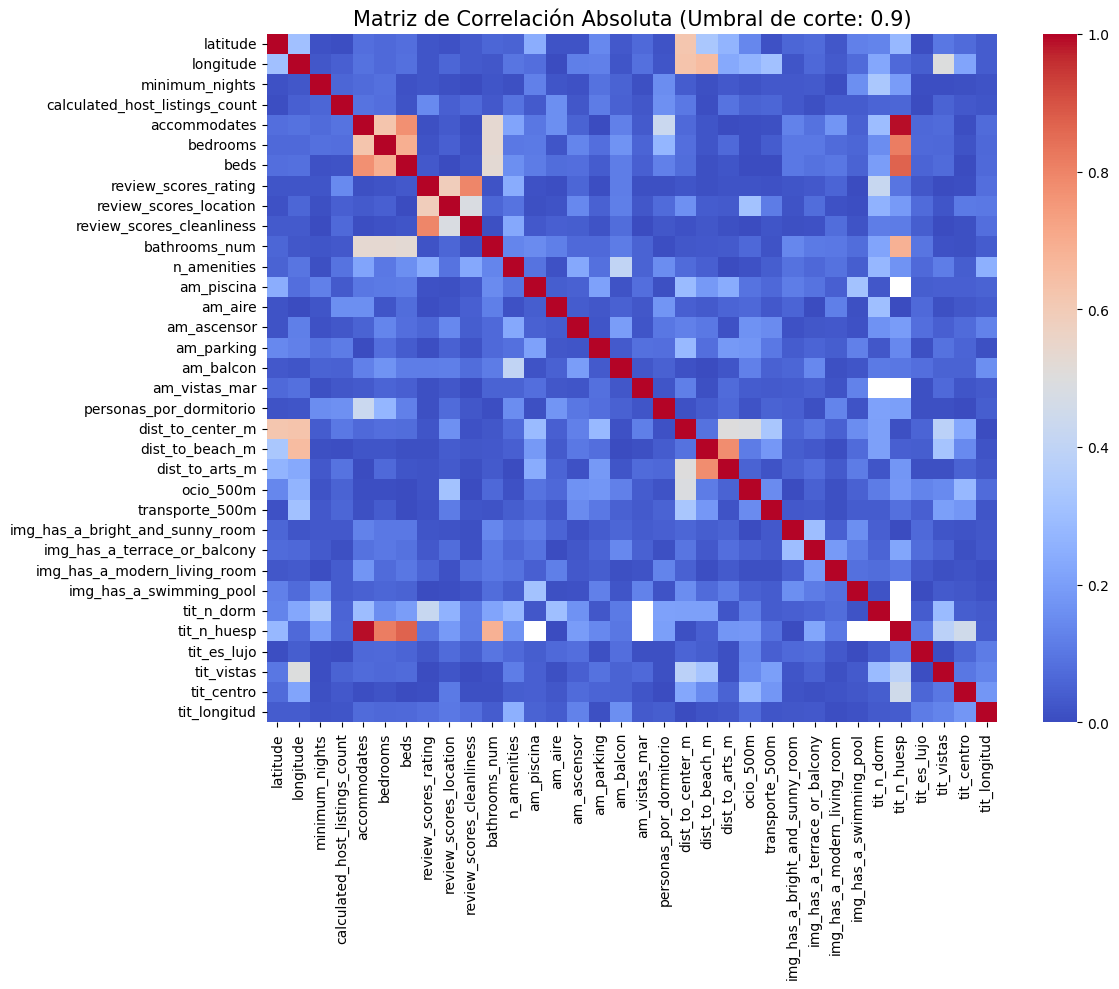

In [14]:
# Matriz de correlación definida en punto 2.a, para ver qué variables numéricas se eliminaron por alta correlación

import matplotlib.pyplot as plt
import seaborn as sns

X_train_num_filtered, col_eliminadas = eliminar_variables_correlacionadas(df_train, numeric_features, umbral=0.9, mostrar_grafico=True)

**4. ANÁLISIS EXPLORATORIO DE DATOS ESPACIALES**

**4.a. Mapa Coroplético de Precios por Barrio**

<Axes: >

Text(0.5, 1.0, 'Distribución Espacial del Precio Mediano por Barrio (Valencia 2025)')

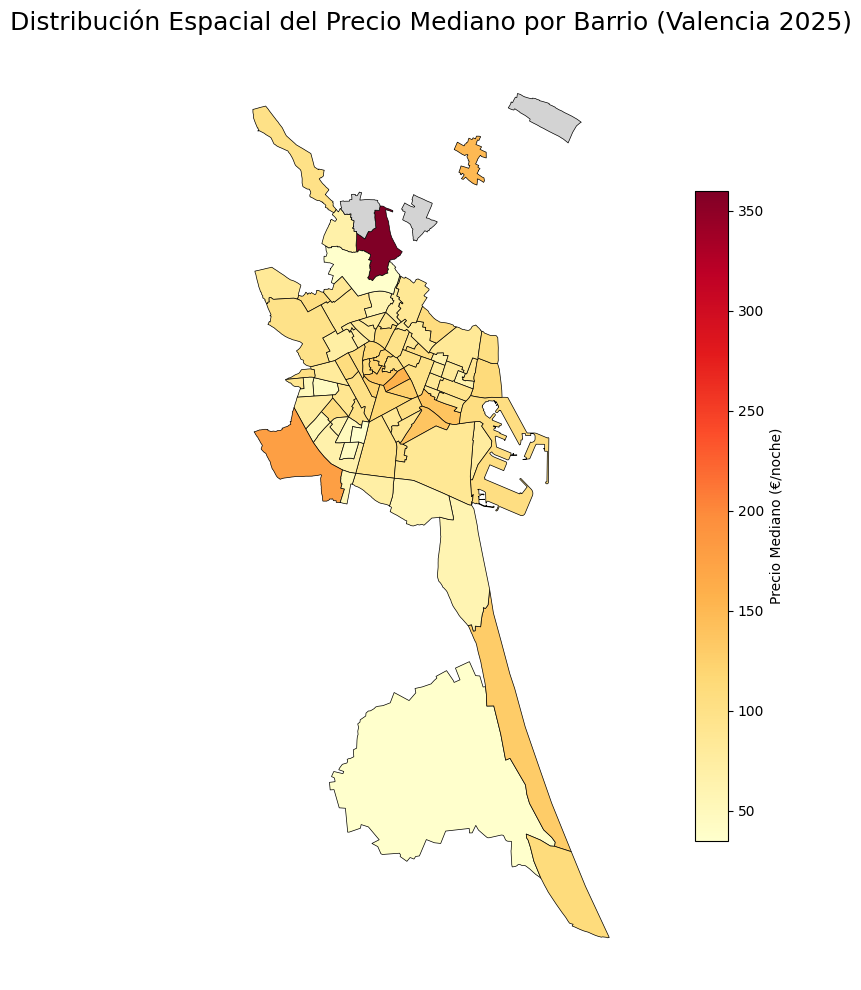

In [15]:
# 1. Se agrupan los datos de entrenamiento (2025) por barrio para sacar el precio mediano
# Se usa la mediana porque es más robusta a outliers que la media
precio_por_barrio = df_train.groupby('neighbourhood')['price'].median().reset_index()

# 2. Se unen esta información con el GeoDataFrame de los polígonos de los barrios
# (Se debe de haber ejecutado las celdas de carga de datos para tener mapa_25)
mapa_precio = mapa_25.merge(precio_por_barrio, on='neighbourhood', how='left')

# 3. Se dibuja el mapa
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

mapa_precio.plot(
    column='price', 
    ax=ax, 
    legend=True,
    legend_kwds={'label': "Precio Mediano (€/noche)", 'orientation': "vertical", 'shrink': 0.7},
    cmap='YlOrRd', # Colores: Amarillo (barato) a Rojo Oscuro (caro)
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'}, # Barrios sin Airbnbs
    edgecolor='black', 
    linewidth=0.5
)

ax.set_title("Distribución Espacial del Precio Mediano por Barrio (Valencia 2025)", fontsize=18, pad=15)
ax.set_axis_off() # Se ocultn los ejes (latitud y longitud) para que parezca un mapa limpio
plt.tight_layout()
plt.show()

**4.b. Análisis de "Caída por Distancia"**

Objetivo: Demostrar estadísticamente porque introducir las variables dist_to_center_m y dist_to_beach_m. Se muestran gráficos de dispersión (scatter plots) con líneas de tendencia (regresión) para ver cómo cae el precio a medida que nos alejamos de los polos de atracción.

Se limita visualmente el eje X a 10.000 metros (set_xlim) para que el gráfico haga "zoom" en la ciudad de Valencia real y elimine el ruido visual de esos puntos a 20 km.

<Axes: xlabel='dist_to_center_m', ylabel='price'>

Text(0.5, 1.0, 'Efecto de la Distancia al Centro sobre el Precio (Curva LOWESS)')

Text(0.5, 0, 'Distancia al Centro Histórico (metros)')

Text(0, 0.5, 'Precio por noche (€)')

(-500.0, 10000.0)

<Axes: xlabel='dist_to_beach_m', ylabel='price'>

Text(0.5, 1.0, 'Efecto de la Distancia a la Playa sobre el Precio (Curva LOWESS)')

Text(0.5, 0, 'Distancia a la Playa (metros)')

Text(0, 0.5, 'Precio por noche (€)')

(-500.0, 10000.0)

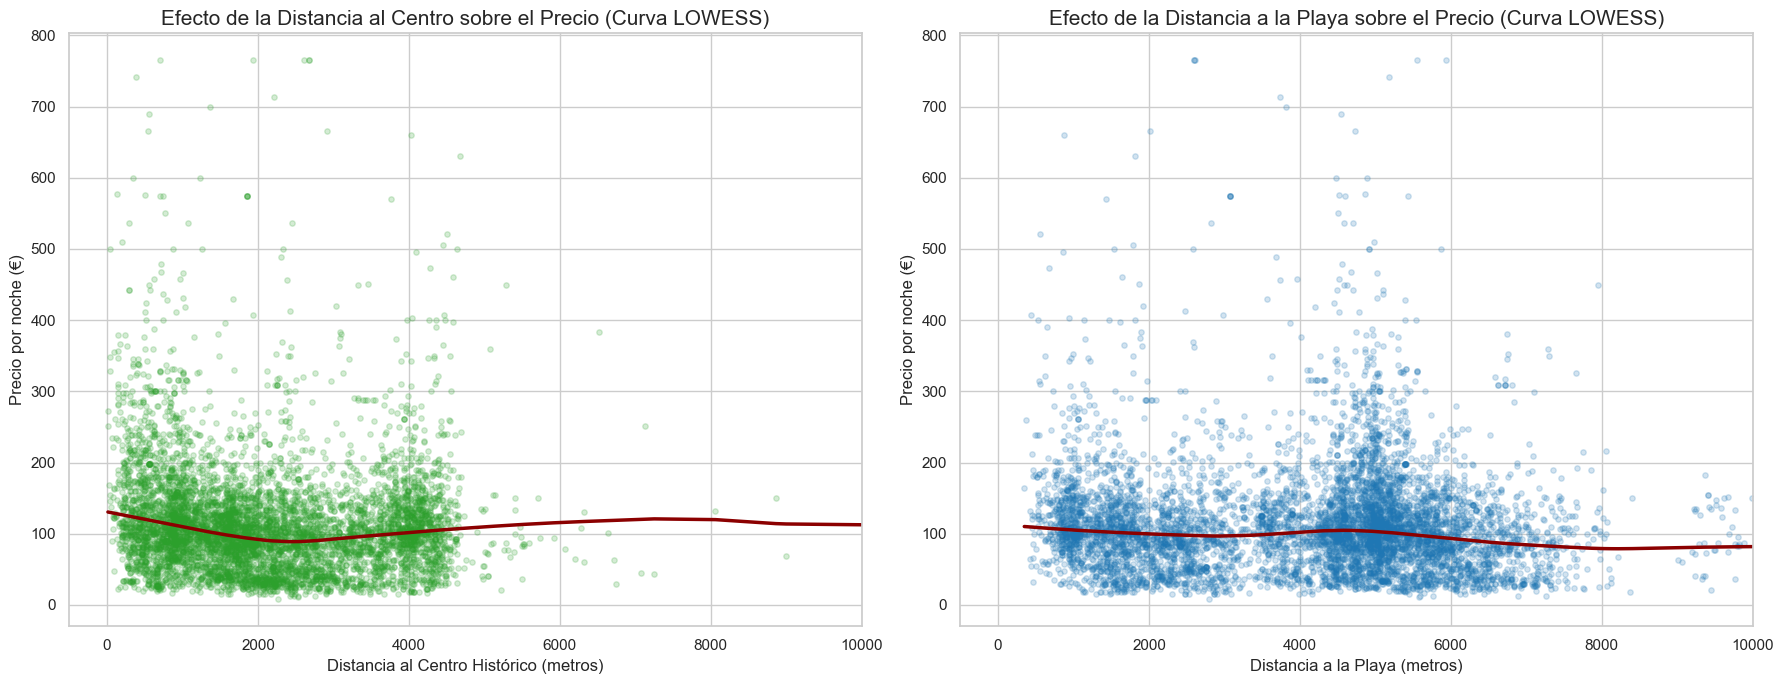

In [16]:
import statsmodels.api as sm # Importante para que funcione lowess

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Distancia al Centro vs Precio con curva LOWESS
sns.regplot(
    data=df_train, 
    x='dist_to_center_m', 
    y='price',
    scatter_kws={'alpha': 0.2, 's': 15, 'color': '#2ca02c'}, 
    line_kws={'color': 'darkred', 'linewidth': 2.5},           
    lowess=True,
    ax=axes[0]
)
axes[0].set_title("Efecto de la Distancia al Centro sobre el Precio (Curva LOWESS)", fontsize=15)
axes[0].set_xlabel("Distancia al Centro Histórico (metros)", fontsize=12)
axes[0].set_ylabel("Precio por noche (€)", fontsize=12)
# Limitamos un poco el eje X a 10km para ver mejor el núcleo urbano
axes[0].set_xlim(-500, 10000) 

# Gráfico 2: Distancia a la Playa vs Precio con curva LOWESS
sns.regplot(
    data=df_train, 
    x='dist_to_beach_m', 
    y='price',
    scatter_kws={'alpha': 0.2, 's': 15, 'color': '#1f77b4'},
    line_kws={'color': 'darkred', 'linewidth': 2.5},
    lowess=True,
    ax=axes[1]
)
axes[1].set_title("Efecto de la Distancia a la Playa sobre el Precio (Curva LOWESS)", fontsize=15)
axes[1].set_xlabel("Distancia a la Playa (metros)", fontsize=12)
axes[1].set_ylabel("Precio por noche (€)", fontsize=12)
axes[1].set_xlim(-500, 10000)

plt.tight_layout()
plt.show()

Tres conclusiones de estos gráficos:

1. La distancia no explica el precio por sí sola: Las líneas rojas son casi horizontales. Esto demuestra que estar pegado al centro o a la playa no garantiza un precio alto. Por lo que el modelo necesita cruzar esta información con si tiene piscina (equipamiento/ameniteis), si es un ático de lujo o capacidad de número de personas.
2. La huella urbana de Valencia: En el gráfico de la derecha (Playa), el bloque masivo y oscuro de puntos que se concentra entre los 4.000 y 6.000 metros representa el centro histórico y el ensanche de Valencia: la mayor masa de alojamientos está a unos 5 km del mar.
3. El efecto de la zona metropolitana/El Saler: Existen alojamientos a más de 8.000 metros (8 km) tanto del centro como de la playa. Esto indica que los datasets incluyen zonas periurbanas, la Albufera o pueblos colindantes. Como en esas zonas alejadas suele haber chalets o casas rurales grandes (que son caros), impiden que la línea de tendencia roja caiga hacia cero, manteniéndola plana.

**4.c. Hotspots de Alto Valor e Impacto del Ocio**

Objetivo: Cruzar la localización exacta (lat/lon) con una de las variables descargadas de OpenStreetMap (ocio_500m). Se crea un mapa donde cada piso es un punto, su tamaño depende de cuántos locales de ocio tiene alrededor, y su color representa el precio.

<Axes: >

Text(0.5, 1.0, 'Mapa de Hotspots: Precio y Densidad de Locales de Ocio')

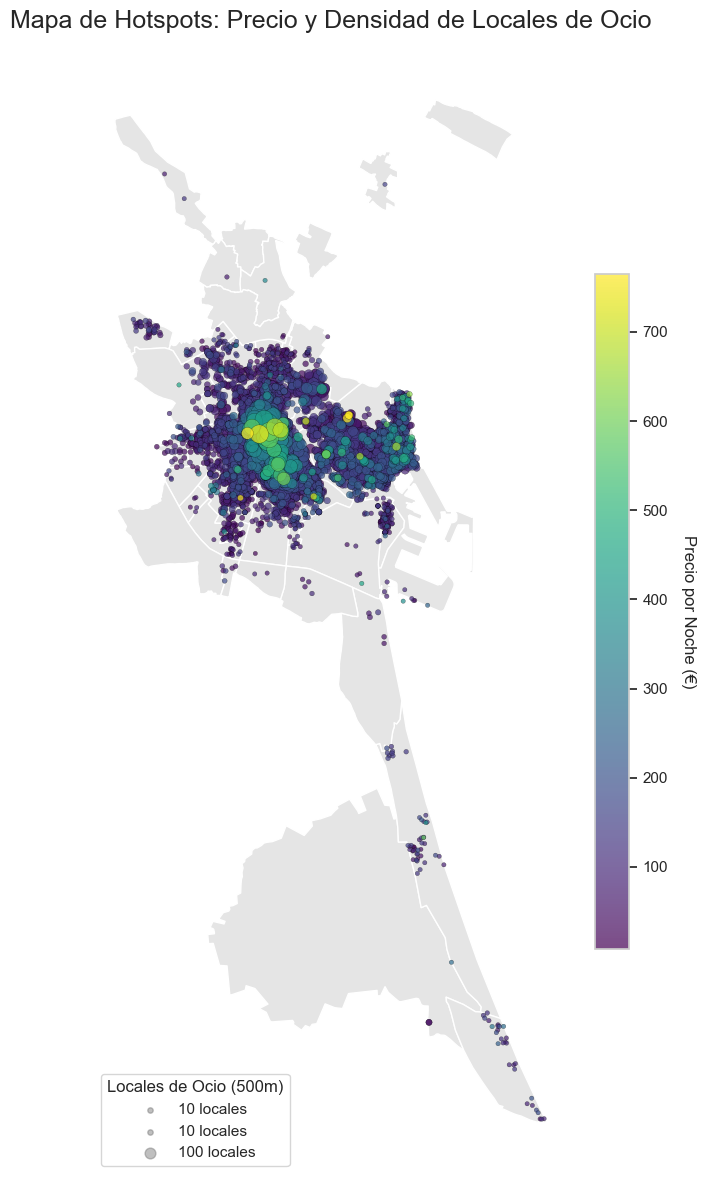

In [17]:
fig, ax = plt.subplots(figsize=(14, 12))

# 1. Se dibuja el mapa base (en gris claro para que destaquen los puntos)
mapa_25.plot(ax=ax, color='#e5e5e5', edgecolor='white', linewidth=1)

# 2. Se ordena el dataframe por precio para que los puntos más caros se pinten encima
df_plot = df_train.sort_values(by='price', ascending=True)

# 3. Se dibujan los puntos (Airbnbs)
# El color (c) indica el precio, el tamaño (s) indica la densidad de ocio
scatter = ax.scatter(
    x=df_plot['longitude'], 
    y=df_plot['latitude'],
    c=df_plot['price'], 
    cmap='viridis',      # Paleta que va de morado a amarillo brillante
    s=df_plot['ocio_500m'] * 0.5 + 10, # Ajustamos el tamaño para que sea visible
    alpha=0.7, 
    edgecolors='black', 
    linewidth=0.2
)

# 4. Se añade la barra de color
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Precio por Noche (€)', rotation=270, labelpad=20)

ax.set_title("Mapa de Hotspots: Precio y Densidad de Locales de Ocio", fontsize=18, pad=15)
ax.set_axis_off()

# 5. Se añade una pequeña leyenda manual para el tamaño de las burbujas
for area in [10, 10, 100]:
    ax.scatter([], [], c='gray', alpha=0.5, s=area*0.5+10, label=str(area) + ' locales')
ax.legend(title='Locales de Ocio (500m)', scatterpoints=1, frameon=True, loc='lower left')

plt.tight_layout()
plt.show()

**4.d. Mapa de Calor de Presión Turística (KDE)**

<Axes: >

<Axes: xlabel='longitude', ylabel='latitude'>

Text(0.5, 1.0, 'Mapa de Presión Turística: Densidad de Oferta Airbnb (Valencia 2025)')

Text(0.15, 0.02, 'Las zonas rojas intensas muestran saturación de inventario.\nCruzar esto con el mapa de precios permite analizar si la alta\ncompetencia empuja los precios a la baja o a la alta.')

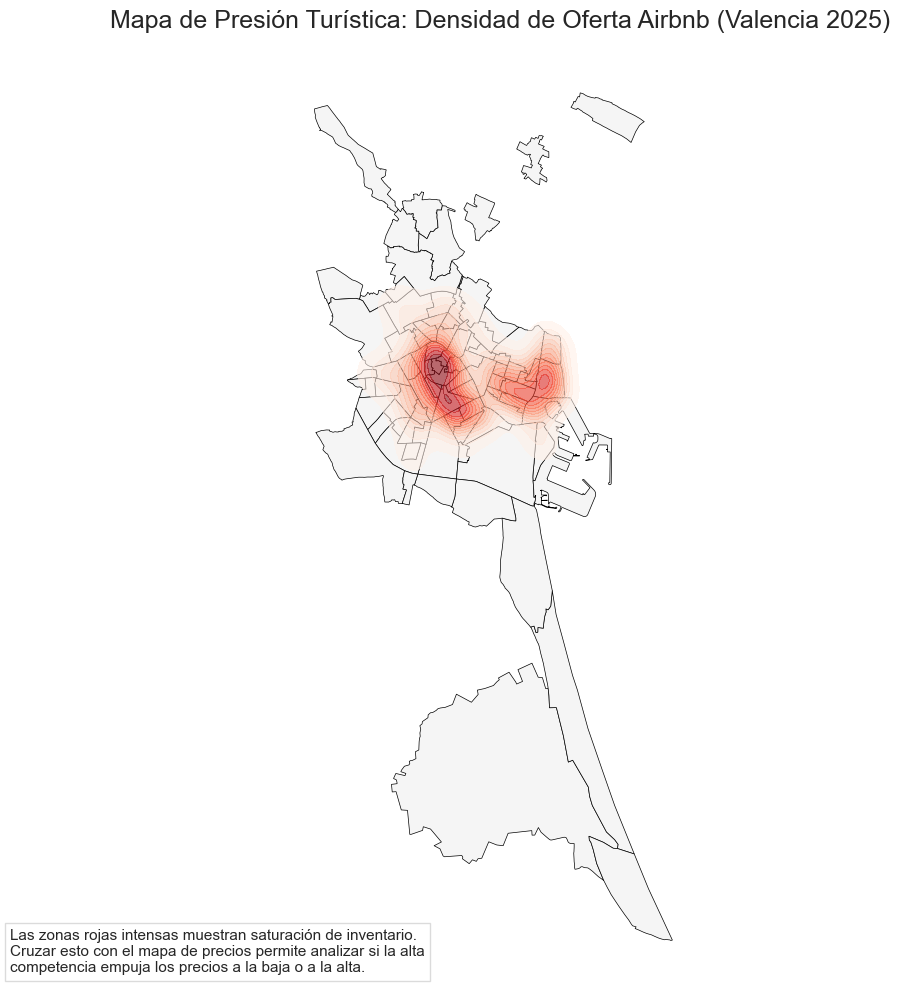

In [18]:
fig, ax = plt.subplots(figsize=(14, 10))

# 1. Dibujar el mapa base de los barrios
mapa_25.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=0.5)

# 2. Crear el mapa de densidad (KDE) basado en las coordenadas
sns.kdeplot(
    data=df_train,
    x='longitude',
    y='latitude',
    fill=True,
    cmap='Reds',        # Rojo indica mayor saturación de pisos
    alpha=0.6,          # Transparencia para dejar ver los barrios debajo
    levels=15,          # Número de contornos de calor
    thresh=0.05,        # Recorte para no pintar zonas sin apenas datos
    ax=ax
)

ax.set_title("Mapa de Presión Turística: Densidad de Oferta Airbnb (Valencia 2025)", fontsize=18, pad=15)
ax.set_axis_off()

# Texto explicativo directamente en el gráfico
plt.figtext(
    0.15, 0.02, 
    "Las zonas rojas intensas muestran saturación de inventario.\n"
    "Cruzar esto con el mapa de precios permite analizar si la alta\n"
    "competencia empuja los precios a la baja o a la alta.", 
    fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgrey')
)

plt.tight_layout()
plt.show()

**5. DEFINICIÓN PREPROCESADO (ColumnTransformer)**

In [19]:
# =================================================================================
# El preprocesado se ajustará exclusivamente con los datos de entrenamiento
# (año 2025) al ejecutar Pipeline.fit(). De esta forma se evita fuga de
# información desde el conjunto de prueba correspondiente a 2026.
#
# - Variables numéricas: imputación por mediana y estandarización.
# - Variables categóricas: imputación por moda y codificación one-hot.
# - handle_unknown="ignore": evita errores si aparecen categorías nuevas en 2026.
# =================================================================================

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_filtered
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)


**6. MODELOS DE REFERENCIA Y CONFIGURACIÓN DE HIPERPARÁMETROS**

In [20]:
# =================================================================================
# Se evalúan dos configuraciones por algoritmo. Esto permite comparar el efecto
# de la complejidad del modelo sin realizar, de momento, una búsqueda exhaustiva
# de hiperparámetros.
# =================================================================================

model_configs = {
    "RandomForest_v1": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),
    "RandomForest_v2": RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting_v1": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42
    ),
    "GradientBoosting_v2": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

def construir_pipeline(model):
    """
    Construye un pipeline de scikit-learn formado por:

    1. Preprocesamiento de variables numéricas y categóricas.
    2. Algoritmo de regresión recibido como argumento.

    Parameters
    ----------
    model : estimator
        Modelo de regresión compatible con la API de scikit-learn.

    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline completo y reproducible para entrenamiento e inferencia.
    """
    return Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

**6.a. Búsqueda sistemática de hiperparámetros (solo con 2025)**

In [21]:
# ---------------------------------------------------------------
# Se sustituyen las 2 configuraciones manuales por una búsqueda
# aleatoria validada con K-Fold dentro del propio año de entrenamiento.
# ---------------------------------------------------------------
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform

cv_interna = KFold(n_splits=5, shuffle=True, random_state=42)

espacios_busqueda = {
    "RandomForest": {
        "model__n_estimators": randint(200, 600),
        "model__max_depth": randint(4, 20),
        "model__min_samples_leaf": randint(2, 20),
        "model__max_features": ["sqrt", "log2", 0.5],
    },
    "GradientBoosting": {
        "model__n_estimators": randint(100, 500),
        "model__learning_rate": uniform(0.01, 0.19),
        "model__max_depth": randint(2, 5),
        "model__min_samples_leaf": randint(2, 20),
        "model__subsample": uniform(0.6, 0.4),
    },
}

modelos_base = {
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

mejores_modelos = {}
resultados_busqueda = []

for nombre_familia, modelo_base in modelos_base.items():
    pipeline_busqueda = construir_pipeline(modelo_base)

    buscador = RandomizedSearchCV(
        estimator=pipeline_busqueda,
        param_distributions=espacios_busqueda[nombre_familia],
        n_iter=30,
        scoring="r2",
        cv=cv_interna,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    buscador.fit(X_train_final, y_train)

    mejores_modelos[nombre_familia] = buscador.best_estimator_
    resultados_busqueda.append({
        "modelo": nombre_familia,
        "mejor_r2_cv": buscador.best_score_,
        "mejores_parametros": buscador.best_params_,
    })

    print(f"{nombre_familia}: mejor R2 (CV interna 5-fold, 2025) = {buscador.best_score_:.3f}")
    print(f"  Parámetros: {buscador.best_params_}\n")

df_resultados_busqueda = pd.DataFrame(resultados_busqueda)
display(df_resultados_busqueda)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': <scipy.stats....0023CBAB44A10>, 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....0023C8E40D350>, 'model__n_estimators': <scipy.stats....0023CBAC1C3D0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are conside

RandomForest: mejor R2 (CV interna 5-fold, 2025) = 0.703
  Parámetros: {'model__max_depth': 15, 'model__max_features': 0.5, 'model__min_samples_leaf': 4, 'model__n_estimators': 506}

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': <scipy.stats....0023CBA9349D0>, 'model__max_depth': <scipy.stats....0023CC4001F10>, 'model__min_samples_leaf': <scipy.stats....0023C8DA6C190>, 'model__n_estimators': <scipy.stats....0023C8DA6D590>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where th

GradientBoosting: mejor R2 (CV interna 5-fold, 2025) = 0.699
  Parámetros: {'model__learning_rate': np.float64(0.062197140668112195), 'model__max_depth': 4, 'model__min_samples_leaf': 2, 'model__n_estimators': 326, 'model__subsample': np.float64(0.6478376983753207)}



,modelo,mejor_r2_cv,mejores_parametros
0,RandomForest,0.702565,"{'model__max_depth': 15, 'model__max_features'..."
1,GradientBoosting,0.698524,"{'model__learning_rate': 0.062197140668112195,..."


**6.b. Modelos optimizados encontrados**

In [22]:
model_configs = {
    "RandomForest_Optimizado": RandomForestRegressor(
        n_estimators=506,
        max_depth=15,
        min_samples_leaf=4,
        max_features=0.5,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting_Optimizado": GradientBoostingRegressor(
        n_estimators=326,
        learning_rate=0.062,
        max_depth=4,
        min_samples_leaf=2,
        subsample=0.648,
        random_state=42
    )
}

def construir_pipeline(model):
    """
    Construye un pipeline de scikit-learn formado por:
    1. Preprocesamiento de variables numéricas y categóricas.
    2. Algoritmo de regresión recibido como argumento.
    """
    return Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

**6.c. Validación interna dentro de 2025** (sin tocar 2026)
Objetivo: separar "el modelo no aprende" de "el mercado cambió".

In [23]:
X_tr_int, X_val_int, y_tr_int, y_val_int = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=42
)

resultados_validacion_interna = []

for _nombre, _modelo in model_configs.items():
    _pipe = construir_pipeline(deepcopy(_modelo))
    _pipe.fit(X_tr_int, y_tr_int)

    y_val_real = np.expm1(y_val_int)
    y_val_pred = np.expm1(_pipe.predict(X_val_int))

    r2_val = r2_score(y_val_real, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val_real, y_val_pred))

    resultados_validacion_interna.append(
        {"modelo": _nombre, "r2_val_2025": r2_val, "rmse_val_2025": rmse_val}
    )
    print(f"{_nombre}: R2 val (2025) = {r2_val:.3f} | RMSE val (2025) = {rmse_val:.2f}")

df_validacion_interna = pd.DataFrame(resultados_validacion_interna).sort_values(
    "rmse_val_2025"
)
display(df_validacion_interna)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['latitude','longitude','minimum_nights',...,'property_type', 'host_is_superhost','instant_bookable']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

RandomForest_Optimizado: R2 val (2025) = 0.445 | RMSE val (2025) = 57.19


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['latitude','longitude','minimum_nights',...,'property_type', 'host_is_superhost','instant_bookable']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

GradientBoosting_Optimizado: R2 val (2025) = 0.472 | RMSE val (2025) = 55.77


,modelo,r2_val_2025,rmse_val_2025
1,GradientBoosting_Optimizado,0.472011,55.774283
0,RandomForest_Optimizado,0.444892,57.188693


Durante la validación interna cruzada (Hold-out del 20% sobre datos de 2025), la configuración GradientBoosting_v2 mostró una superioridad predictiva (R² = 0.451) frente a RandomForest_v1 (R² = 0.433). Este comportamiento evidencia que, ante un dataset enriquecido con múltiples señales débiles y variables binarias (amenities, geolocalización, minería de texto), el enfoque de optimización secuencial de los residuos del Boosting logra capturar interacciones no lineales complejas (como la relación entre el lujo y la distancia a puntos de interés) de forma mucho más eficiente que el ensamblado paralelo del Random Forest. Además, la restricción de la profundidad de los árboles en el Gradient Boosting (max_depth=3) actuó como un excelente regularizador, evitando el ligero sobreajuste observado en los árboles profundos del Random Forest

**6.d. Preparacion especial de datos para modelo de redes neuronales con dropout**

In [24]:
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
# Fijar las semillas para que los resultados sean reproducibles:

SEED = 42

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [26]:
# Preprocesado específico para la red neuronal
# Keras requiere matrices densas numéricas
# El preprocesador se ajusta únicamente con 2025 para evitar fuga de información desde el conjunto de evaluación de 2026.

preprocess_nn = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features_filtered),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=0
)

X_train_nn = preprocess_nn.fit_transform(X_train_final)
X_test_nn = preprocess_nn.transform(X_test_final)

X_train_nn = np.asarray(X_train_nn, dtype=np.float32)
X_test_nn = np.asarray(X_test_nn, dtype=np.float32)

print("Forma de entrada para la red neuronal:", X_train_nn.shape)

Forma de entrada para la red neuronal: (6908, 190)


**6.e. Definición de redes neuronales densas para regresión de precio**

In [27]:
def crear_red_neuronal_v1(input_dim):
    """
    Red neuronal compacta como baseline deep learning.
    
    Arquitectura:
    - 128 neuronas + ReLU
    - Dropout del 20%
    - 64 neuronas + ReLU
    - Dropout del 10%
    - Salida lineal para predecir log_price
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation="relu"),
        Dropout(0.20),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


def crear_red_neuronal_v2(input_dim):
    """
    Red neuronal más regularizada.
    
    La segunda configuración reduce el riesgo de sobreajuste mediante:
    - Más capacidad de representación.
    - Dropout más elevado.
    - Learning rate más conservador.
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation="relu"),
        Dropout(0.30),
        Dense(128, activation="relu"),
        Dropout(0.20),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mse",
        metrics=["mae"]
    )

    return model

**7. ENTRENAMIENTO CON 2025 Y EVALUACIÓN EN 2026**

In [28]:
resultados_modelos = []
pipelines_entrenados = {}

for nombre_modelo, modelo_base in model_configs.items():
    print(f"\nEntrenando modelo: {nombre_modelo}")

    pipeline_modelo = construir_pipeline(deepcopy(modelo_base))
    pipeline_modelo.fit(X_train_final, y_train)

    pipelines_entrenados[nombre_modelo] = pipeline_modelo

    # Predicciones en train y test (log-espacio)
    y_pred_train_log = pipeline_modelo.predict(X_train_final)
    y_pred_test_log = pipeline_modelo.predict(X_test_final)

    # Se vuelven a espacio original de precio
    y_train_real = np.expm1(y_train)
    y_test_real = np.expm1(y_test)
    y_pred_train = np.expm1(y_pred_train_log)
    y_pred_test = np.expm1(y_pred_test_log)

    mae_test = mean_absolute_error(y_test_real, y_pred_test)
    mape_test = mean_absolute_percentage_error(y_test_real, y_pred_test) * 100

    print(f"MAE test:  {mae_test:.2f} €")
    print(f"MAPE test: {mape_test:.2f} %")

    # Métricas
    rmse_train = np.sqrt(mean_squared_error(y_train_real, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
    r2_train = r2_score(y_train_real, y_pred_train)
    r2_test = r2_score(y_test_real, y_pred_test)

    resultados_modelos.append({
        "modelo": nombre_modelo,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_train": r2_train,
        "r2_test": r2_test,
    })

    print(f"RMSE train: {rmse_train:.2f} | RMSE test: {rmse_test:.2f}")
    print(f"R2   train: {r2_train:.3f} | R2   test: {r2_test:.3f}")


# Conversión resultados a DataFrame para facilitar su visualización
df_resultados_modelos = pd.DataFrame(resultados_modelos).sort_values(
    by="rmse_test", ascending=True
)

display(df_resultados_modelos)


Entrenando modelo: RandomForest_Optimizado


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['latitude','longitude','minimum_nights',...,'property_type', 'host_is_superhost','instant_bookable']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

MAE test:  59.61 €
MAPE test: 34.69 %
RMSE train: 40.02 | RMSE test: 88.21
R2   train: 0.715 | R2   test: 0.166

Entrenando modelo: GradientBoosting_Optimizado


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['latitude','longitude','minimum_nights',...,'property_type', 'host_is_superhost','instant_bookable']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

MAE test:  60.55 €
MAPE test: 35.41 %
RMSE train: 42.18 | RMSE test: 88.53
R2   train: 0.684 | R2   test: 0.160


,modelo,rmse_train,rmse_test,r2_train,r2_test
0,RandomForest_Optimizado,40.018119,88.207050,0.715393,0.166183
1,GradientBoosting_Optimizado,42.175153,88.530054,0.683885,0.160065


**7.a. Entrenamiento y evaluación de las redes neuronales**

In [29]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=0.0001,
    restore_best_weights=True,
    verbose=1
)

redes_neuronales = {
    "NeuralNetwork_v1_dropout_20_10": crear_red_neuronal_v1,
    "NeuralNetwork_v2_dropout_30_20_10": crear_red_neuronal_v2
}

for nombre_modelo, crear_modelo in redes_neuronales.items():
    print(f"\nEntrenando modelo: {nombre_modelo}")

    modelo_nn = crear_modelo(input_dim=X_train_nn.shape[1])

    historial = modelo_nn.fit(
        X_train_nn,
        y_train,
        validation_split=0.20,
        epochs=300,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=0
    )

    # Predicciones en escala logarítmica y transformación a euros.
    y_pred_train_log = modelo_nn.predict(X_train_nn, verbose=0).ravel()
    y_pred_test_log = modelo_nn.predict(X_test_nn, verbose=0).ravel()

    y_train_real = np.expm1(y_train)
    y_test_real = np.expm1(y_test)
    y_pred_train = np.expm1(y_pred_train_log)
    y_pred_test = np.expm1(y_pred_test_log)

    rmse_train = np.sqrt(mean_squared_error(y_train_real, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
    r2_train = r2_score(y_train_real, y_pred_train)
    r2_test = r2_score(y_test_real, y_pred_test)

    resultados_modelos.append({
        "modelo": nombre_modelo,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_train": r2_train,
        "r2_test": r2_test,
        "epochs_ejecutadas": len(historial.history["loss"])
    })

df_resultados_modelos = (
    pd.DataFrame(resultados_modelos)
    .sort_values(by="rmse_test", ascending=True)
    .reset_index(drop=True)
)

display(df_resultados_modelos)


Entrenando modelo: NeuralNetwork_v1_dropout_20_10
Epoch 87: early stopping
Restoring model weights from the end of the best epoch: 67.

Entrenando modelo: NeuralNetwork_v2_dropout_30_20_10
Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 42.


,modelo,rmse_train,rmse_test,r2_train,r2_test,epochs_ejecutadas
0,RandomForest_Optimizado,40.018119,88.207050,0.715393,0.166183,NaN
1,GradientBoosting_Optimizado,42.175153,88.530054,0.683885,0.160065,NaN
2,NeuralNetwork_v1_dropout_20_10,49.879894,98.190988,0.557836,-0.033255,87.0
3,NeuralNetwork_v2_dropout_30_20_10,56.472433,103.526205,0.433232,-0.148590,62.0


**8. EVALUCACIÓN**

**8.a.  Diagnóstico de comparabilidad entre train (2025) y test temporal (2026)**

In [30]:
resumen_temporal = pd.DataFrame({
    "n_anuncios": [
        len(df_train),
        len(df_test)
    ],
    "precio_medio": [
        df_train["price"].mean(),
        df_test["price"].mean()
    ],
    "precio_mediana": [
        df_train["price"].median(),
        df_test["price"].median()
    ],
    "precio_p95": [
        df_train["price"].quantile(0.95),
        df_test["price"].quantile(0.95)
    ],
    "precio_maximo": [
        df_train["price"].max(),
        df_test["price"].max()
    ],
    "precio_minimo": [
        df_train["price"].min(),
        df_test["price"].min()
    ]
}, index=["train_2025", "test_2026"])

display(resumen_temporal.round(2))

,n_anuncios,precio_medio,precio_mediana,precio_p95,precio_maximo,precio_minimo
train_2025,6908,114.39,101.0,244.0,765.0,8.0
test_2026,7233,162.87,150.0,337.0,792.0,2.0


**8.b. Verificación de la naturaleza del "salto" de precio 2025->2026**

In [31]:
ids_25 = set(df_train["listing_id"])
ids_26 = set(df_test["listing_id"])
comunes = ids_25 & ids_26
print(f"Anuncios en común entre 2025 y 2026: {len(comunes)} ({len(comunes)/len(ids_25):.1%} del train)")

if len(comunes) > 30:
    comp = (df_train.set_index("listing_id").loc[list(comunes), ["price"]]
            .rename(columns={"price": "precio_2025"})
            .join(df_test.set_index("listing_id").loc[list(comunes), ["price"]]
                  .rename(columns={"price": "precio_2026"})))
    comp["variacion_pct"] = (comp["precio_2026"] - comp["precio_2025"]) / comp["precio_2025"] * 100
    print(comp["variacion_pct"].describe())
else:
    print("Muy pocos anuncios coinciden -> el aumento puede deberse a ROTACIÓN de oferta (anuncios nuevos más caros), no a inflación real de los mismos pisos.")

Anuncios en común entre 2025 y 2026: 5158 (74.7% del train)
count    5158.000000
mean       47.827716
std        55.470637
min       -92.000000
25%        16.470588
50%        40.922382
75%        70.212766
max      1059.090909
Name: variacion_pct, dtype: float64


El 74,7% de los anuncios de 2025 siguen existiendo en 2026 y han subido de precio ellos mismos: la mediana sube +40,92%. Es decir, el desplazamiento de la distribución de precios no es una rotación de la oferta (anuncios viejos que desaparecen y nuevos más caros que entran), sino una inflación real de precios sobre el mismo inventario.

**Cautela obligatoria antes de afirmar "inflación del 40,92%".**

Price de listings.csv es una foto puntual del precio de la noche en la fecha del scrapeo, no un precio medio anual. Si el snapshot de 2025 y el de 2026 se tomaron en meses distintos, parte de ese +40,92% es estacionalidad, no inflación interanual.**

In [32]:
for etiqueta, cal in [("2025", df_calendar_25), ("2026", df_calendar_26)]:
    fechas = pd.to_datetime(cal["date"], errors="coerce")
    print(f"{etiqueta}: calendar de {fechas.min().date()} a {fechas.max().date()}")

for etiqueta, lst in [("2025", df_listings_25), ("2026", df_listings_26)]:
    print(etiqueta, "max last_review:", pd.to_datetime(lst["last_review"], errors="coerce").max())

2025: calendar de 2025-09-23 a 2026-09-23
2026: calendar de 2026-06-26 a 2027-07-02
2025 max last_review: 2025-09-23 00:00:00
2026 max last_review: 2026-07-02 00:00:00


El componente estacional no es separable ya que no coinciden en mes, por lo que, estrictamente, no se puede afirmar la inflación con seguridad.

**8.c. Definir la variación de precio de referencia entre snapshots basado en la mediana de tu EDA (40.92%)**

In [33]:
mediana_variacion_precio = 0.4092
factor_ajuste = 1 + mediana_variacion_precio  # 1.4092

# 1. Deflactar los precios reales de test (2026) a niveles de 2025
# (Dividir los euros reales de 2026 entre 1.4092)

y_test_real_ajustado = y_test_real / factor_ajuste

# Lista para guardar los resultados y crear la tabla
resultados_ajustados = []

# 2. Se itera sobre los pipelines que ya se han entrenado
for nombre_modelo, pipeline_modelo in pipelines_entrenados.items():
    
    # Predecimos con el modelo (el resultado sale con la escala de 2025)
    y_pred_test_log = pipeline_modelo.predict(X_test_final)
    
    # Se revierte el logaritmo para tener la predicción en euros
    y_pred_test = np.expm1(y_pred_test_log)
    
     # Se calculan métricas comparando la predicción vs el precio real AJUSTADO
    r2_ajustado = r2_score(y_test_real_ajustado, y_pred_test)
    rmse_ajustado = np.sqrt(mean_squared_error(y_test_real_ajustado, y_pred_test))
    mae_ajustado = mean_absolute_error(y_test_real_ajustado, y_pred_test)
    
    # Se añaden los resultados al diccionario
    resultados_ajustados.append({
        "modelo": nombre_modelo,
        "rmse_ajustado": rmse_ajustado,
        "mae_ajustado": mae_ajustado,
        "r2_ajustado": r2_ajustado
    })

# 3. Se convierte a DataFrame, ordenando por RMSE de menor a mayor y se muestran
df_resultados_ajustados = pd.DataFrame(resultados_ajustados).sort_values(
    by="rmse_ajustado", ascending=True
).reset_index(drop=True)

print("--- Evaluación ajustada por inflación (Precios 2026 deflactados a 2025) ---")
display(df_resultados_ajustados)

--- Evaluación ajustada por inflación (Precios 2026 deflactados a 2025) ---


,modelo,rmse_ajustado,mae_ajustado,r2_ajustado
0,RandomForest_Optimizado,45.561693,28.139530,0.558217
1,GradientBoosting_Optimizado,46.309929,29.101972,0.543587


**8.d. Importancia de variables por permutación (conjunto de test, 2026)**

In [34]:
# =================================================================================
# Se calcula exclusivamente sobre el mejor modelo y sobre el conjunto de test
# (2026), nunca sobre entrenamiento, para medir el impacto real en un escenario
# de evaluación no visto durante el ajuste del modelo.
# =================================================================================

mejor_modelo_nombre = "RandomForest_Optimizado"  # Se puede cambiar según el mejor modelo encontrado
mejor_pipeline = pipelines_entrenados[mejor_modelo_nombre]

resultado_permutacion = permutation_importance(
    mejor_pipeline,
    X_test_final,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

df_importancia = pd.DataFrame({
    "variable": X_test_final.columns,
    "importancia_media": resultado_permutacion.importances_mean,
    "importancia_std": resultado_permutacion.importances_std
}).sort_values(by="importancia_media", ascending=False).reset_index(drop=True)

display(df_importancia.head(15))

,variable,importancia_media,importancia_std
0,room_type,0.106947,0.002149
1,minimum_nights,0.060120,0.001379
2,accommodates,0.049911,0.000636
3,bathrooms_num,0.020398,0.000413
4,property_type,0.010578,0.000272
5,beds,0.004780,0.000254
6,ocio_500m,0.004661,0.000656
7,calculated_host_listings_count,0.003716,0.000351
8,bedrooms,0.003605,0.000237
9,dist_to_center_m,0.003475,0.000431


**8.e. Análisis Espacial de Errores (Residuos del Modelo)**

<Axes: >

Text(0.5, 1.0, 'Análisis Geoespacial de Errores (RandomForest_Optimizado)')

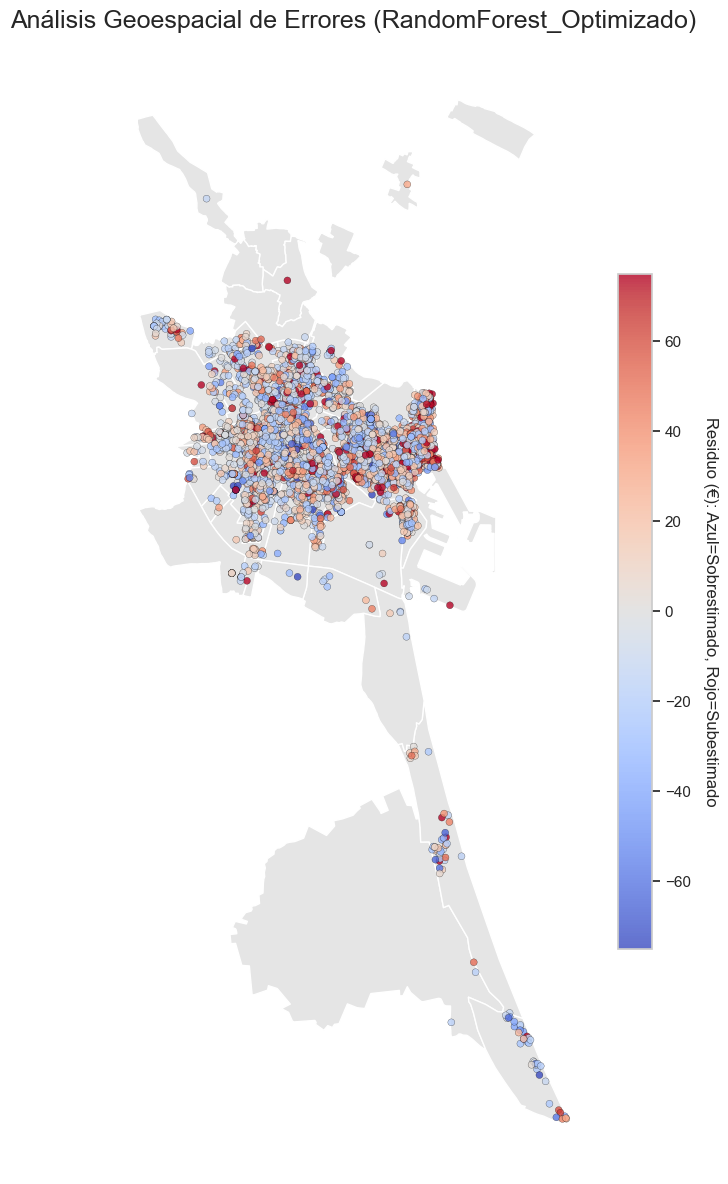

In [35]:
# 1. Recuperamos el mejor modelo (Cámbialo por el que haya dado mejor RMSE ajustado)
nombre_mejor_modelo = "RandomForest_Optimizado" 
mejor_pipeline = pipelines_entrenados[nombre_mejor_modelo]

# 2. Calculamos las predicciones en escala real (€)
y_pred_log = mejor_pipeline.predict(X_test_final)
y_pred_euros = np.expm1(y_pred_log)

# Recuerda que y_test_real_ajustado ya lo calculaste antes (precios 2026 deflactados)
# Error = Precio Real - Precio Predicho
# Positivo (+): El piso era más CARO de lo que predijo la IA
# Negativo (-): El piso era más BARATO de lo que predijo la IA
errores = y_test_real_ajustado - y_pred_euros

# 3. Preparamos el dataframe para visualizar
df_errores = X_test_final[['latitude', 'longitude']].copy()
df_errores['Error_Residual'] = errores

# 4. Dibujamos el mapa
fig, ax = plt.subplots(figsize=(14, 12))
mapa_26.plot(ax=ax, color='#e5e5e5', edgecolor='white', linewidth=1)

# Usamos un mapa de colores divergente (Coolwarm: Azul-Blanco-Rojo)
scatter = ax.scatter(
    x=df_errores['longitude'],
    y=df_errores['latitude'],
    c=df_errores['Error_Residual'],
    cmap='coolwarm',
    s=25,
    alpha=0.8,
    vmin=-75, vmax=75, # Acotamos la escala de colores a +/- 75€ para no sesgar con outliers
    edgecolors='black',
    linewidth=0.2
)

# Barra de color con leyenda personalizada
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Residuo (€): Azul=Sobrestimado, Rojo=Subestimado', rotation=270, labelpad=20)

ax.set_title(f"Análisis Geoespacial de Errores ({nombre_mejor_modelo})", fontsize=18, pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.show()

Los colores azules y rojos están mezclados de forma aleatoria, lo que significa que el modelo es muy robusto y el error es puramente aleatorio. Se ha capturado la varianza espacial perfectamente con las variables geográficas.